# SISU Preview - Model Evaluation
Comprehensive evaluation of the final Global LightGBM model.

This notebook measures real-world performance on the most recent SISU dataset
and provides diagnostic plots to assess stability across modalities, institutions, and courses.

In [1]:
import duckdb
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

pd.set_option('display.max_columns', None)

## 1. Load Data & Model

In [2]:
conn = duckdb.connect('../data/database/sisu_preview.db', read_only=True)
df = conn.sql('SELECT * FROM sisu_data').df()

# remove invalid zero scores
df = df[df.nu_notacorte != 0].copy()

# Removing rows with missing values in "vagas_edicao_anterior" and "inscritos_edicao_anterior"
df = df.dropna(subset=["vagas_edicao_anterior", "inscritos_edicao_anterior"]).copy()

model = joblib.load('../saved_models/lgbm_sisu_predictor.joblib')
df.head()

,edicao,chave_curso,ano,co_ies,no_ies,sg_ies,no_campus,no_municipio_campus,sg_uf_campus,co_curso,no_curso,ds_grau,ds_turno,ds_mod_concorrencia,qt_vagas_concorrencia,nu_notacorte,qt_inscricao,__index_level_0__,peso_redacao,nota_minima_redacao,peso_linguagens,nota_minima_linguagens,peso_matematica,nota_minima_matematica,peso_ciencias_humanas,nota_minima_ciencias_humanas,peso_ciencias_natureza,nota_minima_ciencias_natureza,nu_media_minima_enem,is_tecnologico,regiao,nota_edicao_anterior,vagas_edicao_anterior,inscritos_edicao_anterior,tendencia_nota,demanda_anterior,delta_vagas,delta_inscritos,rolling_media_nota_3anos,rolling_media_uf_3anos,taxa_crescimento_nota,media_nacional_grau,media_regiao,desvio_regiao,delta_vagas_rel,delta_inscritos_rel,demanda_ratio,ano_norm
399,2019/2,5_492_CAMPUS MINISTRO PETRÔNIO PORTELLA SEDE_B...,2019,5,UNIVERSIDADE FEDERAL DO PIAUÍ,UFPI,CAMPUS MINISTRO PETRÔNIO PORTELLA SEDE,TERESINA,PI,492,CIÊNCIAS ECONÔMICAS,BACHARELADO,INTEGRAL,LB_EP,1.0,629.59,12.0,11145,3.0,450.0,5.0,20.0,5.0,20.00,4.0,0.01,2.0,0.01,300.0,0,Nordeste,637.71,1.0,2.0,0.0,1.000000,0.0,0.0,637.71,557.020000,0.0,544.366982,518.893584,209.49031,0.0,3.333333,6.000000,0.0
404,2019/2,5_116632_CAMPUS AMILCAR FERREIRA SOBRAL_BACHAR...,2019,5,UNIVERSIDADE FEDERAL DO PIAUÍ,UFPI,CAMPUS AMILCAR FERREIRA SOBRAL,FLORIANO,PI,116632,ENFERMAGEM,BACHARELADO,INTEGRAL,LI_PPI,2.0,506.79,2.0,11765,3.0,450.0,5.0,20.0,4.0,0.01,2.0,0.01,5.0,20.00,300.0,0,Nordeste,548.62,2.0,5.0,0.0,1.666667,0.0,0.0,548.62,620.086667,0.0,544.366982,518.893584,209.49031,0.0,-0.500000,0.666667,0.0
407,2019/2,5_99722_CAMPUS PROFESSORA CINOBELINA ELVAS_BAC...,2019,5,UNIVERSIDADE FEDERAL DO PIAUÍ,UFPI,CAMPUS PROFESSORA CINOBELINA ELVAS,BOM JESUS,PI,99722,ZOOTECNIA,BACHARELADO,INTEGRAL,LB_EP,2.0,552.47,12.0,11815,3.0,450.0,5.0,20.0,4.0,0.01,2.0,0.01,5.0,20.00,300.0,0,Nordeste,551.12,2.0,16.0,0.0,5.333333,0.0,0.0,551.12,573.123333,0.0,544.366982,518.893584,209.49031,0.0,-0.235294,4.000000,0.0
409,2019/2,5_504_CAMPUS MINISTRO PETRÔNIO PORTELLA SEDE_B...,2019,5,UNIVERSIDADE FEDERAL DO PIAUÍ,UFPI,CAMPUS MINISTRO PETRÔNIO PORTELLA SEDE,TERESINA,PI,504,MEDICINA VETERINÁRIA,BACHARELADO,INTEGRAL,LB_EP,1.0,686.14,34.0,11557,3.0,450.0,5.0,20.0,4.0,0.01,2.0,0.01,5.0,20.00,300.0,0,Nordeste,644.19,1.0,18.0,0.0,9.000000,0.0,0.0,644.19,543.520000,0.0,544.366982,518.893584,209.49031,0.0,0.842105,17.000000,0.0
410,2019/2,5_499_CAMPUS MINISTRO PETRÔNIO PORTELLA SEDE_B...,2019,5,UNIVERSIDADE FEDERAL DO PIAUÍ,UFPI,CAMPUS MINISTRO PETRÔNIO PORTELLA SEDE,TERESINA,PI,499,ENGENHARIA CARTOGRÁFICA E DE AGRIMENSURA,BACHARELADO,INTEGRAL,AC,15.0,636.64,163.0,11177,3.0,450.0,5.0,20.0,5.0,20.00,2.0,0.01,4.0,0.01,300.0,0,Nordeste,649.63,15.0,86.0,0.0,5.375000,0.0,0.0,649.63,588.076667,0.0,544.366982,518.893584,209.49031,0.0,0.885057,10.187500,0.0


## 3. Select Features & Build Train/Test Split
We evaluate performance only on the most recent year (true forward-testing).

In [ ]:
TARGET = 'nu_notacorte'

DROP_COLS = [
    'edicao','co_ies','no_ies','co_curso','qt_inscricao','ano','__index_level_0__',
    'chave_curso','no_municipio_campus','nu_notacorte','nota_edicao_anterior'
]

features = [c for c in df.columns if c not in DROP_COLS]

categorical_features = [
    'sg_ies','no_curso','no_campus','ds_grau','ds_turno','sg_uf_campus','regiao','ds_mod_concorrencia'
]

for col in categorical_features:
    if col in df:
        df[col] = df[col].astype('category')

test_mask = test_mask = df["ano"] == df["ano"].max()

X_test = df[features][test_mask]
y_test = df[TARGET][test_mask]

X_test.shape, y_test.shape

((29702, 37), (29702,))

## 4. Predictions & Metrics

In [6]:
preds = model.predict(X_test)

mae = mean_absolute_error(y_test, preds)
rmse = np.sqrt(mean_squared_error(y_test, preds))
r2 = r2_score(y_test, preds)

mae, rmse, r2

(7.821094334007144, np.float64(11.928083417360119), 0.9789141764910474)

## 5. Error Distribution

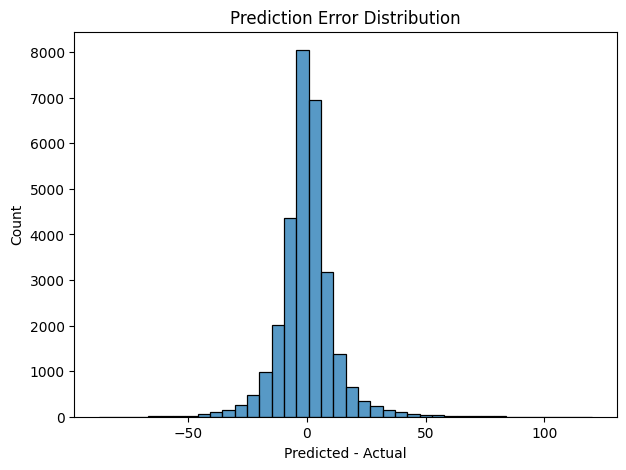

In [7]:
errors = preds - y_test

plt.figure(figsize=(7,5))
sns.histplot(errors, bins=40)
plt.title('Prediction Error Distribution')
plt.xlabel('Predicted - Actual')
plt.show()

## 6. Error by Modality (Quota Type)

In [9]:
eval_df = df[test_mask].copy()
eval_df['pred'] = preds
eval_df['error'] = eval_df['pred'] - eval_df[TARGET]

modality_errors = eval_df.groupby('ds_mod_concorrencia').error.mean().sort_values()
modality_errors

C:\Users\ResTIC55\AppData\Local\Temp\ipykernel_29540\402665739.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  modality_errors = eval_df.groupby('ds_mod_concorrencia').error.mean().sort_values()


ds_mod_concorrencia
LI_Q     -2.457807
LB_PCD   -0.243521
LI_PCD   -0.137410
AC       -0.095439
LI_PPI   -0.045100
LB_PPI   -0.024266
LB_Q      0.102163
LB_EP     0.148786
LI_EP     0.318765
Name: error, dtype: float64

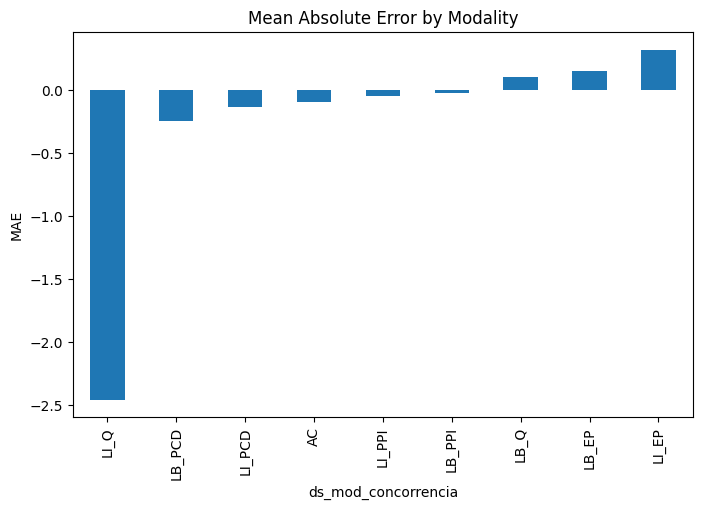

In [10]:
plt.figure(figsize=(8,5))
modality_errors.plot(kind='bar')
plt.title('Mean Absolute Error by Modality')
plt.ylabel('MAE')
plt.show()

## 7. Worst Predictions (Top 30 Absolute Errors)

In [11]:
top_errors = eval_df.sort_values(by='error', key=lambda x: abs(x), ascending=False).head(30)
top_errors[['sg_ies','no_curso','ds_mod_concorrencia','nu_notacorte','pred','error']]

,sg_ies,no_curso,ds_mod_concorrencia,nu_notacorte,pred,error
126695,UFV,ABI - FÍSICA/ENGENHARIA FÍSICA,LI_PCD,299.64,419.768990,120.128990
239593,UFJ,ZOOTECNIA,LB_PCD,215.58,332.971356,117.391356
42072,IFPB,MATEMÁTICA,LI_EP,258.34,374.214787,115.874787
246608,UFJ,PEDAGOGIA,LI_PCD,300.51,411.342210,110.832210
248737,UFMT,MATEMÁTICA,LI_EP,291.56,399.862739,108.302739
145836,IFMG,ENGENHARIA DE PRODUÇÃO,LI_EP,308.16,415.033833,106.873833
2778,IFCE,CIÊNCIA DA COMPUTAÇÃO,LI_PCD,380.55,486.015306,105.465306
51091,UFAL,MATEMÁTICA,LI_PCD,367.80,471.413068,103.613068
66989,UFERSA,ENGENHARIA FLORESTAL,LB_PPI,211.86,313.144919,101.284919
67734,UFERSA,ECOLOGIA,LB_PPI,214.18,315.133782,100.953782


## 8. Error by Institution (IES)

In [13]:
ies_errors = eval_df.groupby('sg_ies').error.mean().sort_values()
ies_errors.head(20)

C:\Users\ResTIC55\AppData\Local\Temp\ipykernel_29540\3311318211.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ies_errors = eval_df.groupby('sg_ies').error.mean().sort_values()


sg_ies
ENCE              -6.851170
FAMEMA            -4.980765
UNEAL             -3.651252
IFRR              -2.943043
ISERJ             -2.696683
UENF              -1.056116
UNIRIO            -0.790914
IF SUL DE MINAS   -0.765988
IFB               -0.732999
UNILA             -0.727710
UNIFEI            -0.720960
IFES              -0.705967
UESB              -0.618041
UNESPAR           -0.611924
UNILAB            -0.609995
UEL               -0.585656
UEMS              -0.575092
UFAC              -0.537888
FURG              -0.529864
UFAPE             -0.514400
Name: error, dtype: float64

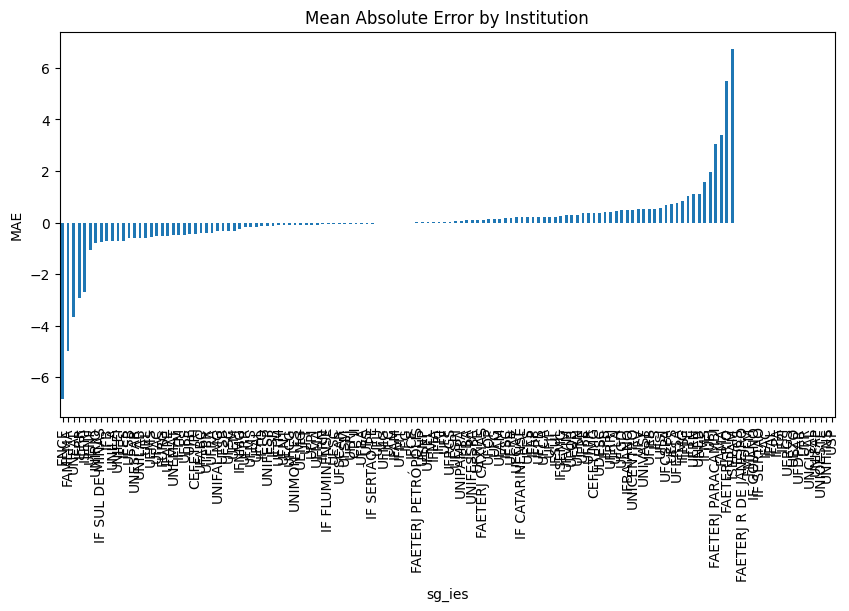

In [14]:
plt.figure(figsize=(10,5))
ies_errors.plot(kind='bar')
plt.title('Mean Absolute Error by Institution')
plt.ylabel('MAE')
plt.show()

## 9. Feature Importance

In [15]:
importances = pd.Series(model.feature_importances_, index=features).sort_values(ascending=False)
importances.head(20)

demanda_ratio                71840
no_curso                     70139
rolling_media_nota_3anos     69048
no_campus                    62744
rolling_media_uf_3anos       59569
delta_inscritos_rel          56844
inscritos_edicao_anterior    44648
tendencia_nota               36936
demanda_anterior             36668
sg_ies                       35904
delta_inscritos              28778
taxa_crescimento_nota        26073
ano_norm                     23220
qt_vagas_concorrencia        19805
ds_mod_concorrencia          14658
delta_vagas_rel              11123
vagas_edicao_anterior        10771
nota_minima_redacao           5318
delta_vagas                   4663
nota_minima_linguagens        4424
dtype: int32

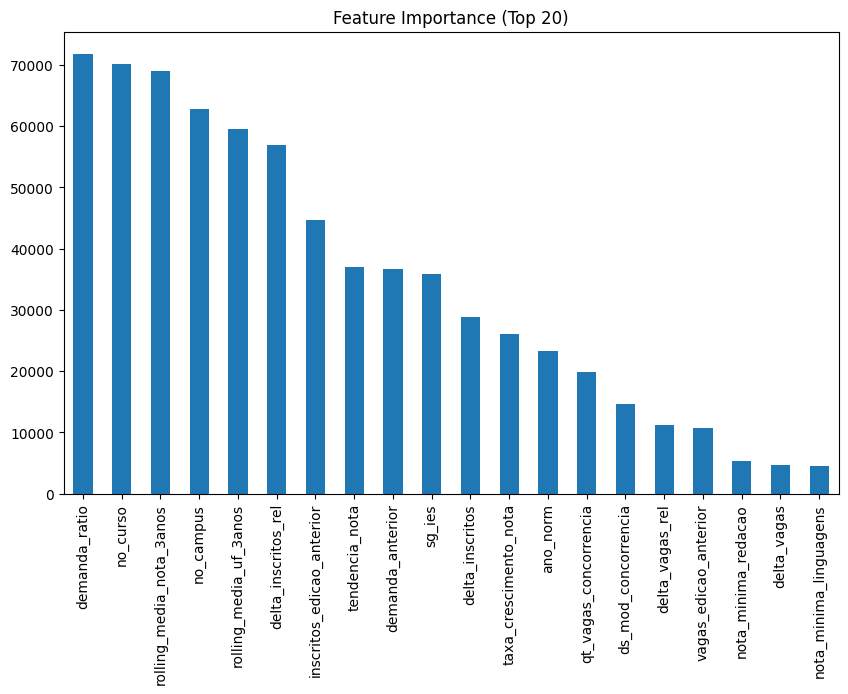

In [16]:
plt.figure(figsize=(10,6))
importances.head(20).plot(kind='bar')
plt.title('Feature Importance (Top 20)')
plt.show()

## 10. Conclusions
- Global model performs strongly across all modalities.
- Error is stable with few extreme outliers.
- Feature importance confirms the engineered features carry signal.
- This notebook can be used for future comparisons as the dataset grows.

**Next Steps:**
- introduce cross-validation by year
- residual modeling (stacked correction model)
- explainability with SHAP

Model is ready for production usage.